# Section A: Data Loading and Exploration

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# Load dataset
df = pd.read_csv('diamonds.csv', index_col=0)

# Create a copy (before any changes)
df_original = df.copy()

# Display first 10 rows
df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


### Displaying Dataset Information

In [85]:
# Number of rows and columns
print("Shape (rows, columns):", df.shape)

# Data types of each column
print("\nData types")
print(df.dtypes)

# Summary statistics of numerical variables
print("\nSummary statistics (numericals)")
df.describe()

Shape (rows, columns): (53940, 10)

Data types
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Summary statistics (numericals)


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Identify and display missing values

In [86]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({'Missing Values Count': missing_values, 'Percentage of Missing Values': missing_percent})
missing_values_df[missing_values_df['Missing Values Count'] > 0]

,Missing Values Count,Percentage of Missing Values


Interpretation: The dataset has no missing values

# Section B: Data Cleaning and Preprocessing

### a) Duplicate records

In [87]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 146
Shape after removing duplicates: (53794, 10)


**No duplicates were found**

### b) Handling missing value
Since there are no missing values, no imputation is needed. However, if there were missing values, we would
- **Numerical columns**: Replace missing values with the median because it is robust to outliers and represents the central tendency well.
- **Categorical columns**: Replace missing values with the mode (most frequent value) as it preserves the majority distribution.

### c) Convert categorical variables to numerical
Categorical columns: cut, color, clarity

In [88]:
# Define Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['cut', 'color', 'clarity']

In [89]:
from sklearn.preprocessing import LabelEncoder

# One-hot encoding for columns with fewer than 10 unique values
for col in cat_cols:
    if df[col].nunique() < 10:
        df = pd.get_dummies(df, columns=[col])

# Label encoding for columns with more than 10 unique values
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns and df[col].nunique() > 10:
        df[col] = le.fit_transform(df[col])

# Coverting the encoded boolean columns to integers (0/1)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [90]:
df.head(10)

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
1,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0.23,56.9,65.0,327,4.05,4.07,2.31,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,0,...,1,0,0,0,0,0,0,1,0,0
5,0.31,63.3,58.0,335,4.34,4.35,2.75,0,1,0,...,0,1,0,0,0,1,0,0,0,0
6,0.24,62.8,57.0,336,3.94,3.96,2.48,0,0,0,...,0,1,0,0,0,0,0,0,0,1
7,0.24,62.3,57.0,336,3.95,3.98,2.47,0,0,0,...,1,0,0,0,0,0,0,0,1,0
8,0.26,61.9,55.0,337,4.07,4.11,2.53,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9,0.22,65.1,61.0,337,3.87,3.78,2.49,1,0,0,...,0,0,0,0,0,0,0,1,0,0
10,0.23,59.4,61.0,338,4.00,4.05,2.39,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Section C: Exploratory Data Analysis

### a) Correlation matrix for all numerical variables

In [91]:
corr_matrix = df.corr()
corr_matrix

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
carat,1.000000,0.027861,0.181091,0.921548,0.975380,0.951908,0.953542,0.090910,0.033026,-0.162477,...,0.160591,0.180773,0.121186,-0.114294,0.062859,0.266458,-0.062818,-0.038390,-0.167533,-0.136930
depth,0.027861,1.000000,-0.297669,-0.011048,-0.025348,-0.029389,0.094757,0.278303,0.136778,-0.022489,...,0.023060,0.022647,0.082061,-0.030869,0.040715,0.007034,-0.023926,-0.009807,-0.023351,-0.019041
table,0.181091,-0.297669,1.000000,0.126566,0.194855,0.183231,0.150270,0.126107,0.174854,-0.549647,...,0.017521,0.037363,0.044735,-0.078517,0.051883,0.095222,-0.026993,-0.009665,-0.068859,-0.062076
price,0.921548,-0.011048,0.126566,1.000000,0.884504,0.865395,0.861208,0.017940,-0.001106,-0.096179,...,0.096283,0.081899,-0.000231,-0.049342,0.008946,0.127639,-0.009694,-0.000724,-0.095106,-0.052215
x,0.975380,-0.025348,0.194855,0.884504,1.000000,0.974592,0.970686,0.079911,0.029669,-0.161548,...,0.145633,0.165204,0.108423,-0.125824,0.079372,0.270185,-0.059716,-0.035077,-0.185235,-0.147125
y,0.951908,-0.029389,0.183231,0.865395,0.974592,1.000000,0.951844,0.068086,0.031533,-0.152040,...,0.142017,0.161281,0.100774,-0.120641,0.076208,0.262645,-0.056328,-0.035523,-0.179239,-0.141587
z,0.953542,0.094757,0.150270,0.861208,0.970686,0.951844,1.000000,0.109307,0.044573,-0.157541,...,0.144442,0.164764,0.112083,-0.125093,0.081095,0.262534,-0.058305,-0.035930,-0.182367,-0.144692
cut_Fair,0.090910,0.278303,0.126107,0.017940,0.079911,0.068086,0.109307,1.000000,-0.055335,-0.142701,...,0.004872,0.017623,0.176746,-0.026903,0.004823,0.054553,-0.022067,-0.027503,-0.039782,-0.030466
cut_Good,0.033026,0.136778,0.174854,-0.001106,0.029669,0.031533,0.044573,-0.055335,1.000000,-0.257921,...,0.005675,0.014910,0.015387,-0.032933,0.055857,0.041660,-0.017227,-0.020654,-0.037446,-0.038488
cut_Ideal,-0.162477,-0.022489,-0.549647,-0.096179,-0.161548,-0.152040,-0.157541,-0.142701,-0.257921,1.000000,...,-0.008814,-0.038476,-0.048745,0.104577,-0.083060,-0.107177,0.034297,0.015497,0.087898,0.075097


### b) Five most positively correlated with price

In [92]:
# Sort correlations with price (excluding price itself)
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("Top 5 positive correlations with price:")
print(price_corr.head(5))

Top 5 positive correlations with price:
carat          0.921548
x              0.884504
y              0.865395
z              0.861208
clarity_SI2    0.127639
Name: price, dtype: float64


### c) Five most negatively correlated with price

In [93]:
print("Bottom 5 (most negative) correlation with price:")
print(price_corr.tail(5))

Bottom 5 (most negative) correlation with price:
clarity_VVS2   -0.052215
color_D        -0.072085
clarity_VVS1   -0.095106
cut_Ideal      -0.096179
color_E        -0.100852
Name: price, dtype: float64


### d) Group analysis by cut

In [94]:
group_analysis = df_original.groupby('cut')['price'].agg(['mean', 'median', 'std']).round(2)
group_analysis

,mean,median,std
cut,,,
Fair,4358.76,3282.0,3560.39
Good,3928.86,3050.5,3681.59
Ideal,3457.54,1810.0,3808.40
Premium,4584.26,3185.0,4349.20
Very Good,3981.76,2648.0,3935.86


# Section D: Data Visualization

### a) Histogram of price

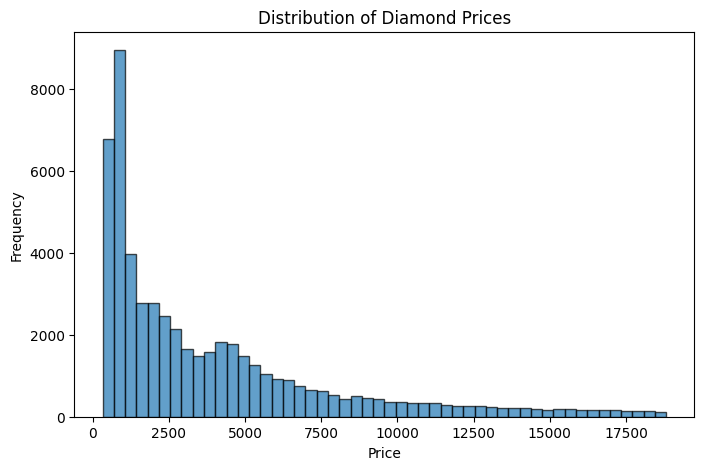

In [95]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### Comment on the Distribution
The distribution of diamond prices is positively skewed (right-skewed). Most diamonds are concentrated in the lower price range, while a smaller number of diamonds have very high prices, creating a long tail on the right side of the histogram.   

### b) Scatter plot of carat vs price with regression line

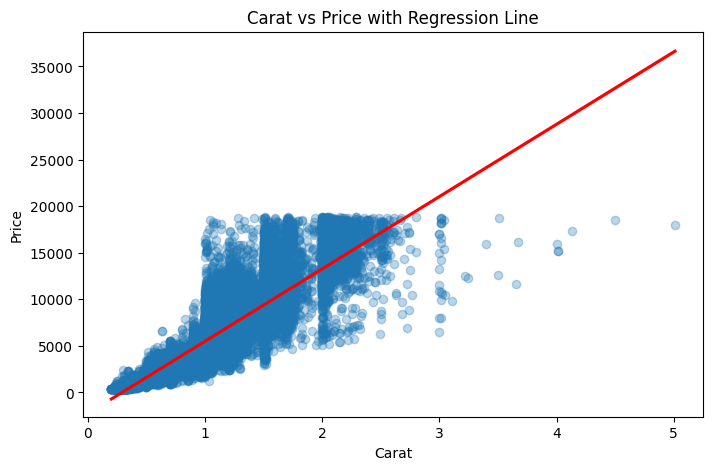

In [96]:
plt.figure(figsize=(8,5))
sns.regplot(x='carat', y='price', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Carat vs Price with Regression Line')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()

### Interpretation of the Relationship Between Carat and Price
The scatter plot shows a strong positive linear relationship between carat and price. As carat increases, the price tends to increase as well. The regression line confirms this updward trend, though the points fan out at higer carat values, indicating increasing variance (heteroscedasticity) meaning price becomes more variable for larger diamonds.

### c) Box plots for price across categories

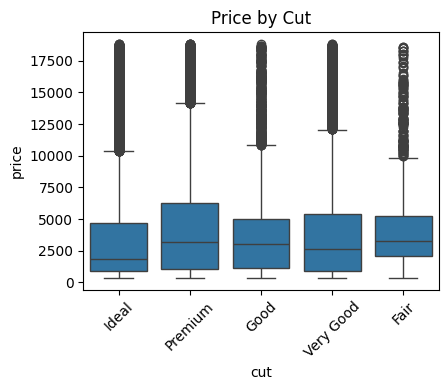

In [97]:
# Price vs cut
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.boxplot(x='cut', y='price', data=df_original)
plt.title('Price by Cut')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

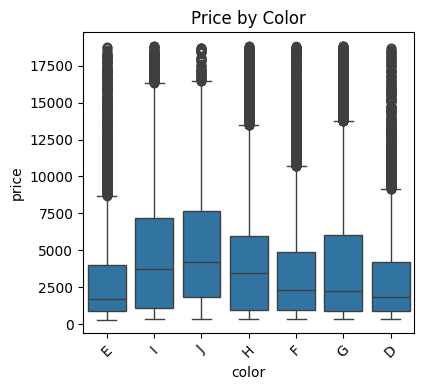

In [98]:
# Price vs color
plt.figure(figsize=(12,4))
plt.subplot(1,3,2)
sns.boxplot(x='color', y='price', data=df_original)
plt.title('Price by Color')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

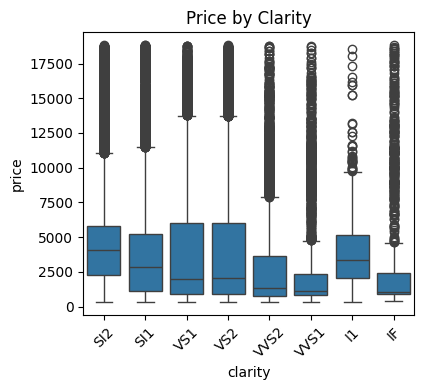

In [99]:
# Price vs clarity
plt.figure(figsize=(12,4))
plt.subplot(1,3,2)
sns.boxplot(x='clarity', y='price', data=df_original)
plt.title('Price by Clarity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpreting the price variations between these categories
**Price by Cut**
- **Premium:** This cut show the highest median price, premium having a notably large interquartile range, suggesting a wide variety of pricing within that tier
- **Ideal:** Ideal diamonds show a lower median price than the rest in this dataset
- **Consistency:** The **Good, Very Good**, and **Fair** categories maintain relatively similar median prices, hovering between 2,500 and 5,000.

**Price by Color**
- **J and I:** these colors exhibit the highest median prices and the largest IQRs.
- **D and E:** These have lower median prices.
- **Distribution:** colors **H, F**, and **G** show moderate median prices, sitting roughly between 2,500 and 5,000.

**Price by Clarity**
- **SI2 and I1:** These show higher median prices compared to **IF** or **VVS1** grades.
- **VS1 and VS2:** These grades show the widest price distribution and higher upper whiskers before outliers begin.
- **High Clarity:** **VVS1, VVS2,** and **IF** show lower median prices and more compressed IQRs.

# Section E: Advanced Visualization and Insights

### a) Heatmap of correlation matrix

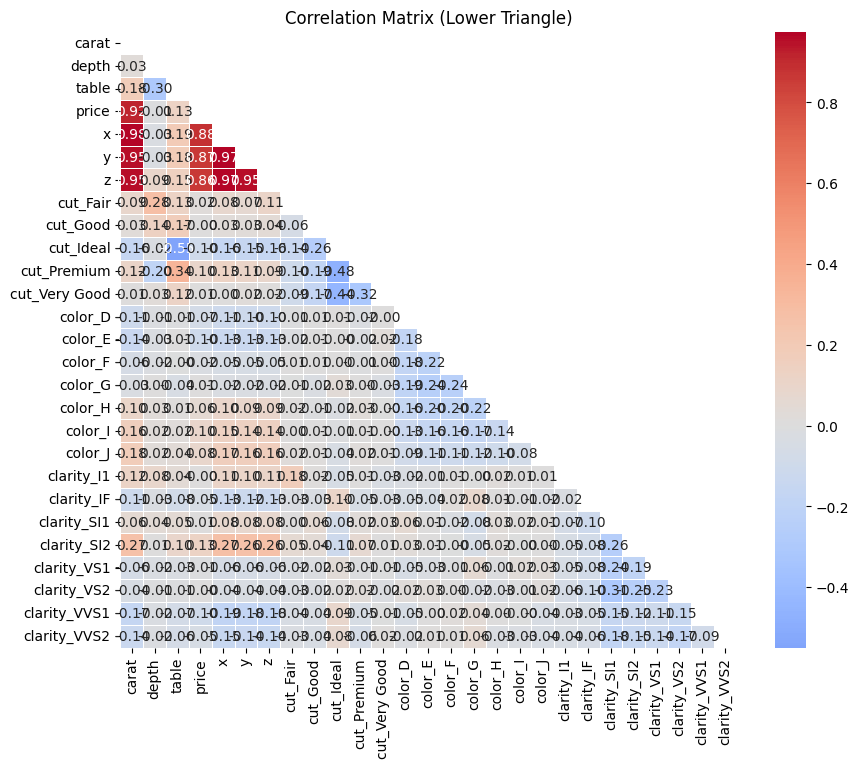

In [100]:
import numpy as np
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
#sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Lower Triangle)')

plt.show()

## Correlations ( > 0.5 or < -0.5 )

| Variable 1 | Variable 2 | Correlation Coefficient |
|-------------|-------------|-------------------------|
| Price | Carat | 0.92 |
| Price | x (length) | 0.88 |
| Price | y (width) | 0.86 |
| Price | z (depth) | 0.86 |
| Carat | x (length) | 0.97 |
| Carat | y (width) | 0.95 |
| Carat | z (depth) | 0.95 |
| x | y | 0.97 |
| x | z | 0.97 |
| y | z | 0.95 |

---

## Notable Relationships

- There is an extremely strong positive correlation between **carat and price (0.92)**, confirming that as a diamond's weight increases, its price rises significantly.
- The dimensions **(x, y, and z)** are almost perfectly correlated with each other (**0.95 – 0.97**). This indicates that diamonds typically scale proportionally in all directions.
- Categorical Variables (Cut, Color, Clarity): Interestingly, none of the specific **cut, color, or clarity grades** show a correlation greater than **0.5** or less than **-0.5** with price. This suggests that while these factors influence value, they do not have the same strong linear impact on price as **physical size and weight**.

### b) Pairplot for selected variables

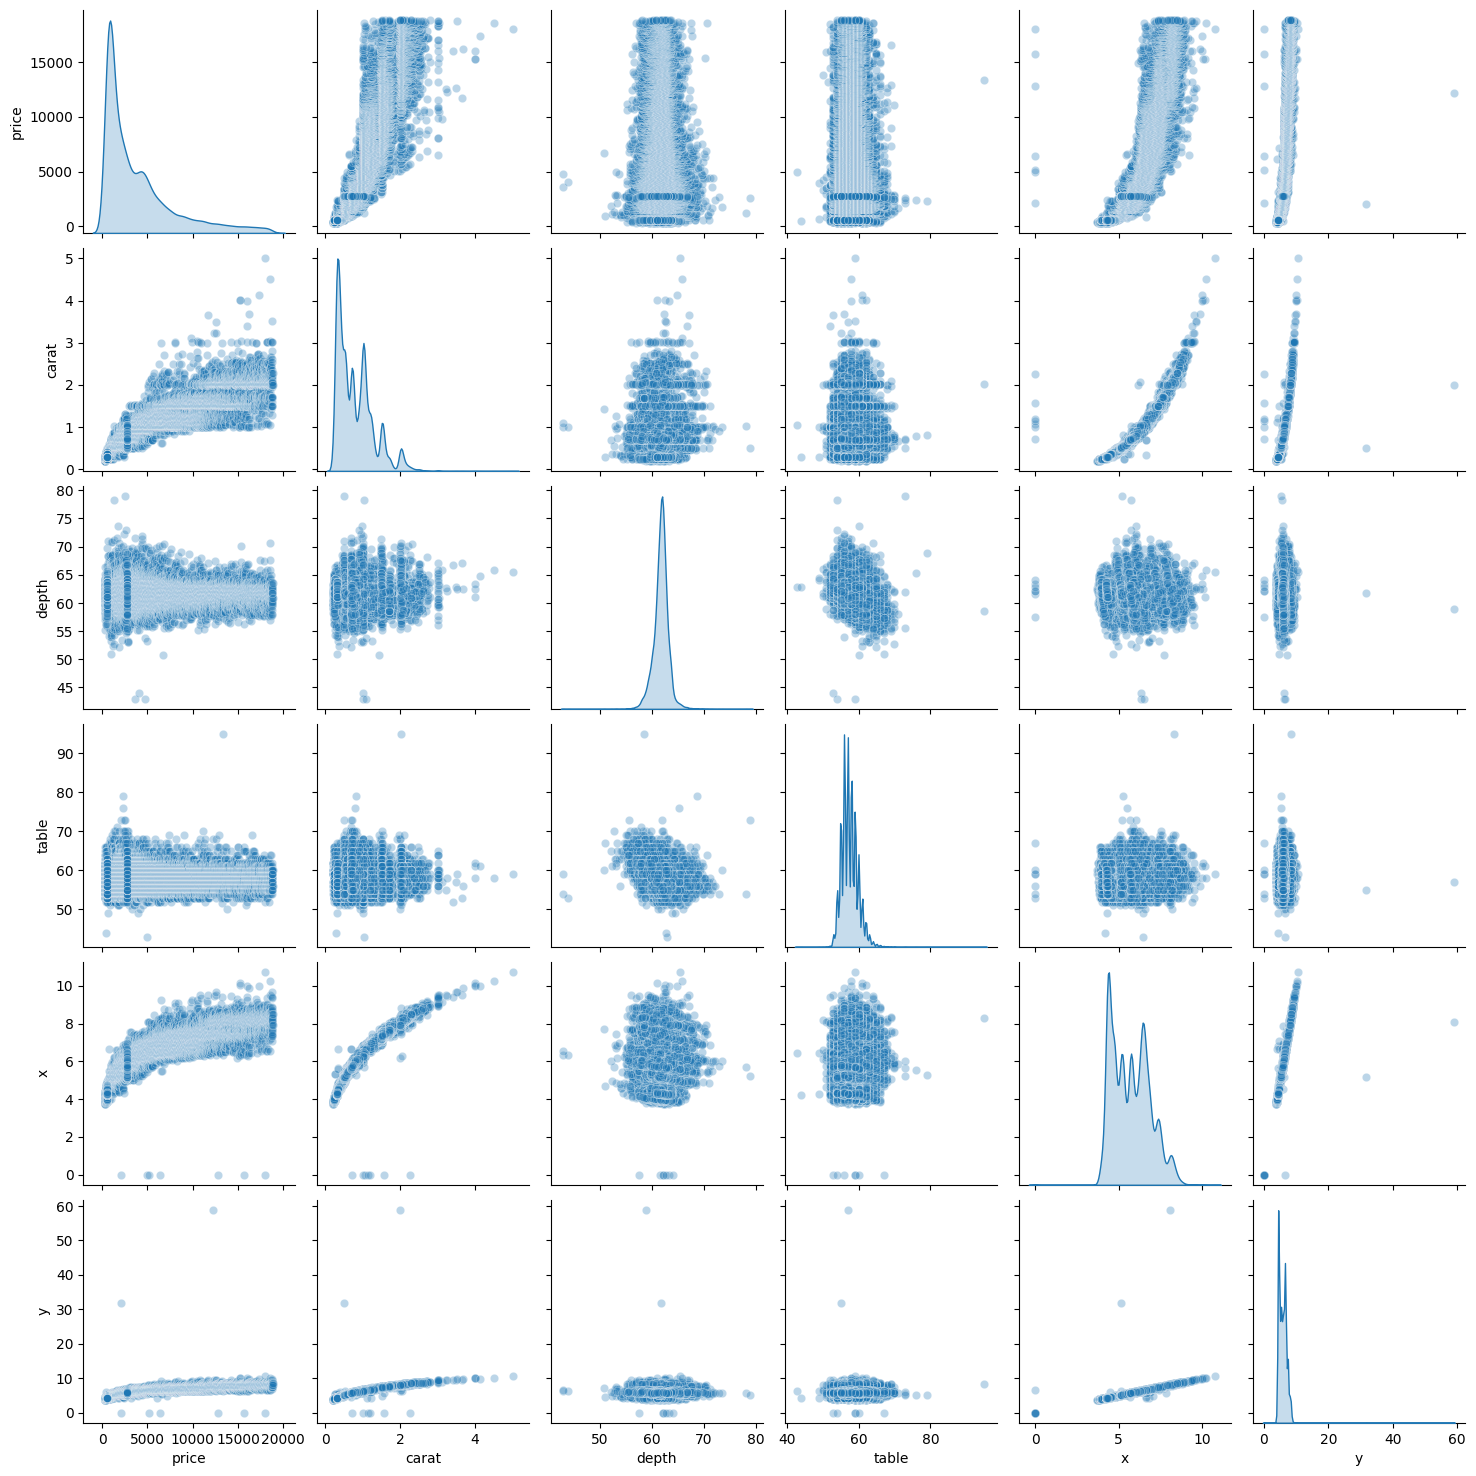

In [101]:
# Select variables for pairplot
pair_vars = ['price', 'carat', 'depth', 'table', 'x', 'y']
sns.pairplot(df[pair_vars], diag_kind='kde', plot_kws={'alpha':0.3})
plt.show()

# Observation of Important Patterns and Relationship

## 1. Exponential Relationship Between Price and Carat

The scatter plot for **price vs. carat** shows a distinct **non-linear, upward-curving trend**.

- As **carat weight increases**, the **price does not rise steadily** but appears to **accelerate**.
- There is a **high concentration of diamonds with carat values under 1.0** and **lower price ranges**.
- Larger diamonds show **greater price variation**, meaning their prices vary widely compared to smaller diamonds.

## 2. Linear Physical Scaling (x, y, and Carat)

The **physical dimensions of diamonds** demonstrate extremely **strong linear relationships**.

- The plots for **x vs. carat** and **y vs. carat** show a **very narrow and clear linear pattern**, indicating that **physical size strongly determines weight**.
- The relationship between **x and y** is **almost a perfect straight line**, confirming that most diamonds maintain **consistent proportional dimensions (length-to-width ratios)**.

## 3. Constant Proportions (Depth and Table)

Unlike price and size, the attributes **depth** and **table** show more **clustered distributions** when plotted against other variables.

- **Depth and table percentages remain relatively stable** regardless of the diamond's **size or price**.
- This is visible in the **vertical and horizontal clustering** seen in scatter plots.
- The values remain within a **narrow range**:
  - **Depth:** approximately **55–65**
  - **Table:** approximately **50–70**